In [1]:
# ! pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Напиши код, который выполнит следующие шаги:

Шаг А: Заполни пропущенные значения (NaN) в столбце age средним возрастом по всей таблице.

Шаг Б: Отфильтруй таблицу: оставь только тех пользователей, у которых сумма покупок (purchase_amount) строго больше 1000 И которые живут НЕ в Казани.

Шаг В: Сгруппируй полученный отфильтрованный датасет по столбцу is_premium и посчитай медиану (не среднее, а именно медиану) суммы покупок для премиум и обычных пользователей.

In [3]:
# Наш «сырой» датасет
raw_data = {
    'user_id': [101, 102, 103, 104, 105, 106, 107],
    'city': ['Москва', 'Санкт-Петербург', 'Москва', 'Казань', 'Санкт-Петербург', 'Москва', 'Казань'],
    'age': [24, np.nan, 31, 45, 22, np.nan, 38], # np.nan — это пропуск в данных
    'purchase_amount': [2500, 12000, 500, 0, 4300, 15000, 1100],
    'is_premium': [False, True, False, False, True, True, False]
}

df = pd.DataFrame(raw_data)
print(df)

   user_id             city   age  purchase_amount  is_premium
0      101           Москва  24.0             2500       False
1      102  Санкт-Петербург   NaN            12000        True
2      103           Москва  31.0              500       False
3      104           Казань  45.0                0       False
4      105  Санкт-Петербург  22.0             4300        True
5      106           Москва   NaN            15000        True
6      107           Казань  38.0             1100       False


In [4]:
print(df.age.mean())

32.0


In [5]:
df.age = df['age'].fillna(df['age'].mean())  # Заполняем пропуски средним возрастом

df_filtered = df[(df['purchase_amount'] > 1000) & (df['city'] != 'Казань')]  # Фильтруем пользователей с покупками больше 1000 и не из Казани

print(df_filtered.groupby('is_premium')['purchase_amount'].median())  # Группируем по признаку "премиум" и считаем медиану суммы покупок

is_premium
False     2500.0
True     12000.0
Name: purchase_amount, dtype: float64


Задание №2: Работа со временем и типами данных (Неделя 2)
В реальных логах почти всегда есть даты. Нам нужно научить тебя правильно с ними работать, так как во временных рядах и аналитике это 50% успеха.

Представь, что к нашему датасету добавился столбец с датой регистрации пользователя, но он пришел в виде обычного текста (строк).

Напиши код, который выполнит шаги:

Шаг А: Переведи столбец reg_date из типа данных object (строка) в настоящий формат даты datetime (используй pd.to_datetime).

Шаг Б: Создай новый столбец reg_year, в который запиши только год регистрации (извлеки его из reg_date).

Шаг В: Отфильтруй датасет, оставив только тех пользователей, которые зарегистрировались в 2026 году.

In [6]:
data_v2 = {
    'user_id': [101, 102, 103, 104, 105],
    'reg_date': ['2025-01-15', '2025-03-20', '2026-02-10', '2026-05-01', '2024-12-01'],
    'purchase_amount': [2500, 12000, 500, 3000, 4300]
}

df2 = pd.DataFrame(data_v2)

In [7]:
print(df2)

   user_id    reg_date  purchase_amount
0      101  2025-01-15             2500
1      102  2025-03-20            12000
2      103  2026-02-10              500
3      104  2026-05-01             3000
4      105  2024-12-01             4300


In [8]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_id          5 non-null      int64
 1   reg_date         5 non-null      str  
 2   purchase_amount  5 non-null      int64
dtypes: int64(2), str(1)
memory usage: 252.0 bytes


In [9]:
df2['reg_year'] = pd.to_datetime(df2['reg_date']).dt.year  # Извлекаем год из даты регистрации
df2_filtered = df2[(df2['reg_year'] == 2026)]
print(df2_filtered)

   user_id    reg_date  purchase_amount  reg_year
2      103  2026-02-10              500      2026
3      104  2026-05-01             3000      2026


Неделя 3: Спринт "Объединение данных (Слияния в стиле SQL)"
В реальной жизни данные не лежат в одной таблице. Информация о пользователях хранится в одной таблице, а данные об их покупках (транзакциях) — в другой. Чтобы построить модель, дата-сайентисту нужно уметь их правильно склеивать.

В Pandas для этого используется метод .merge(), который работает в точности как JOIN в SQL.

🛠️ Твое задание:
У тебя есть две таблицы: users (справочник клиентов) и transactions (история покупок). Обрати внимание, что кто-то из пользователей не делал покупок, а по кому-то из покупателей нет данных в справочнике клиентов.

Скопируй исходные данные:

In [10]:
# Таблица А: Клиенты
users = pd.DataFrame({
    'user_id': [101, 102, 103, 104],
    'name': ['Алексей', 'Мария', 'Иван', 'Елена'],
    'city': ['Москва', 'Сочи', 'Казань', 'Красноярск']
})

# Таблица Б: Транзакции (покупок может быть несколько на одного user_id)
transactions = pd.DataFrame({
    'transaction_id': [1, 2, 3, 4, 5],
    'user_id': [101, 102, 101, 105, 102], # Игнат (105) купил, но его нет в users
    'item': ['Смартфон', 'Ноутбук', 'Наушники', 'Книга', 'Чехол'],
    'price': [30000, 70000, 5000, 1000, 1500]
})

Напиши код, который выполнит шаги:

Шаг А (Inner Join): Объедини таблицы так, чтобы в результате остались только те строки, где user_id есть в обеих таблицах. Выведи результат.

Шаг Б (Left Join): Объедини таблицы так, чтобы сохранились все клиенты из таблицы users, даже если они ничего не купили (у них в столбцах транзакций появятся пропуски NaN). Выведи результат.

Шаг В (Агрегация): Используя таблицу из Шага Б, посчитай общую сумму затрат (price) для каждого города (city). Подсказка: пропуски NaN при суммировании Pandas проигнорирует автоматически.

In [11]:
print(users)
print(transactions)

   user_id     name        city
0      101  Алексей      Москва
1      102    Мария        Сочи
2      103     Иван      Казань
3      104    Елена  Красноярск
   transaction_id  user_id      item  price
0               1      101  Смартфон  30000
1               2      102   Ноутбук  70000
2               3      101  Наушники   5000
3               4      105     Книга   1000
4               5      102     Чехол   1500


In [24]:
inner_join = pd.merge(users, transactions, on='user_id', how='inner')  # Внутреннее соединение
print(inner_join)
print()
left_join = pd.merge(users, transactions, on='user_id', how='left')  # Левое соединение
print(left_join)
print()
print(left_join.groupby('city')['price'].sum())  # Суммируем покупки по городам


   user_id     name    city  transaction_id      item  price
0      101  Алексей  Москва               1  Смартфон  30000
1      101  Алексей  Москва               3  Наушники   5000
2      102    Мария    Сочи               2   Ноутбук  70000
3      102    Мария    Сочи               5     Чехол   1500

   user_id     name        city  transaction_id      item    price
0      101  Алексей      Москва             1.0  Смартфон  30000.0
1      101  Алексей      Москва             3.0  Наушники   5000.0
2      102    Мария        Сочи             2.0   Ноутбук  70000.0
3      102    Мария        Сочи             5.0     Чехол   1500.0
4      103     Иван      Казань             NaN       NaN      NaN
5      104    Елена  Красноярск             NaN       NaN      NaN

city
Казань            0.0
Красноярск        0.0
Москва        35000.0
Сочи          71500.0
Name: price, dtype: float64


📊 Модуль 2: Переход к Разведочному анализу (EDA) и Статистике
Ты отлично справляешься с базовым манипулированием данными. Пора переходить на следующий уровень. Представь, что мы закончили предобработку и теперь должны исследовать данные перед тем, как скармливать их алгоритмам машинного обучения.

Этот этап называется EDA (Exploratory Data Analysis). Здесь мы ищем аномалии, выбросы и скрытые зависимости.

🛠️ Твое задание (Борьба с выбросами):
В Data Science «выбросы» (outliers) — это аномальные значения, которые могут сильно исказить предсказания модели (например, если у всех зарплата 50 000 руб, а у одного человека 5 000 000 руб).

У тебя есть данные по возрасту кандидатов на вакансию. Некоторые значения там явно ошибочные (кто-то ввел лишний ноль или опечатку).

Скопируй исходный датасет:

In [25]:
df_candidates = pd.DataFrame({
    'candidate_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'age': [22, 25, 190, 30, 28, 5, 35, 42, 29, 31] 
    # Обрати внимание на возраст 190 и 5 — это явные аномалии (выбросы)
})

Напиши код, который выполнит шаги:

Шаг А: Посчитай классическое среднее значение столбца age.

Шаг Б: Посчитай медиану столбца age. Напиши в комментариях к коду, какой показатель (среднее или медиана) оказался более устойчивым к экстремальным выбросам (190 и 5).

Шаг В: Отфильтруй датасет, удалив аномалии. Оставь только тех кандидатов, чей возраст находится в разумных пределах: от 18 до 70 лет включительно.

In [29]:
print(df_candidates)

   candidate_id  age
0             1   22
1             2   25
2             3  190
3             4   30
4             5   28
5             6    5
6             7   35
7             8   42
8             9   29
9            10   31


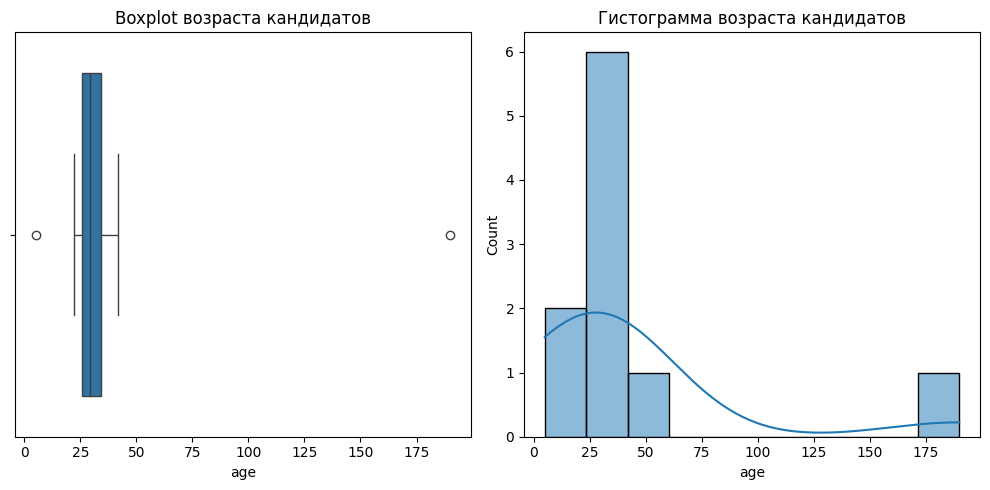

In [30]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_candidates['age'])
plt.title('Boxplot возраста кандидатов')
plt.subplot(1, 2, 2)
sns.histplot(df_candidates['age'], bins=10, kde=True)
plt.title('Гистограмма возраста кандидатов')
plt.tight_layout()
plt.show()